# Paper 2: Machine Learning–Based Flood Risk Assessment in Contrasting Terrains: Chennai and Uttarkashi

## Step 1-4: Data Processing Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

import warnings
warnings.filterwarnings('ignore')

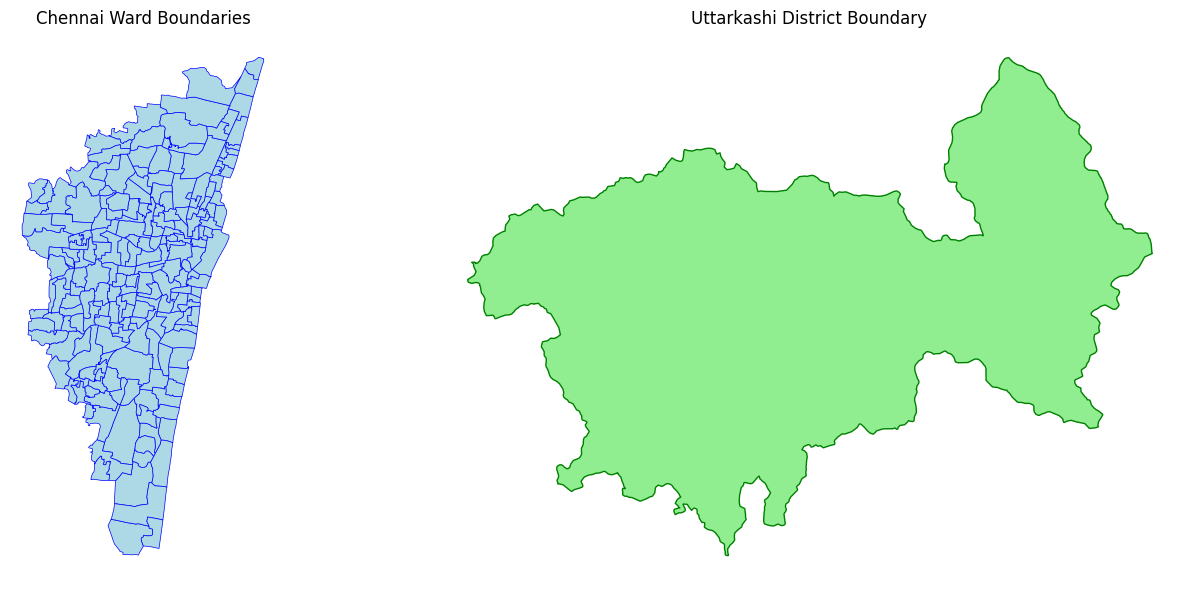

In [2]:
# Load the GeoJSON files
chennai_gdf = gpd.read_file('geojson/Chennai.geojson')
uk_state_gdf = gpd.read_file('geojson/Uttarakhand.geojson')

# Extract ONLY Uttarkashi from the Uttarakhand state file
uttarkashi_gdf = uk_state_gdf[uk_state_gdf['Dist_Name'] == 'Uttarkashi']

# Plot to verify boundaries
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

chennai_gdf.plot(ax=axes[0], color='lightblue', edgecolor='blue', linewidth=0.5)
axes[0].set_title("Chennai Ward Boundaries")
axes[0].axis('off') 

uttarkashi_gdf.plot(ax=axes[1], color='lightgreen', edgecolor='green')
axes[1].set_title("Uttarkashi District Boundary")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [3]:
def load_and_clean_data(filepath, boundary_gdf, location_col_name):
    df = pd.read_csv(filepath)
    df = df.rename(columns={'valid_time': 'Date', 'tp': 'Rainfall'})
    df['Rainfall'] = df['Rainfall'].fillna(0) * 1000
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y %H:%M', errors='coerce')
    df = df.dropna(subset=['Date', 'latitude', 'longitude'])
    
    # Convert tabular data into a spatial GeoDataFrame
    weather_gdf = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
        crs="EPSG:4326"
    )
    
    # Ensure map boundaries match the GPS coordinate system
    boundary_gdf = boundary_gdf.to_crs("EPSG:4326")
    
    # Spatial Join: Match weather points to the exact Ward/District polygon
    joined_gdf = gpd.sjoin(weather_gdf, boundary_gdf, how="inner", predicate="within")
    
    # Group by Date AND location (e.g., Ward_No) to get local max rainfall
    df_spatial = joined_gdf.groupby(['Date', location_col_name])['Rainfall'].max().reset_index()
    df_spatial.set_index('Date', inplace=True)
    
    # Aggregate to Daily Rainfall per unique location
    df_daily = pd.DataFrame()
    df_daily['Daily_Total_Rain'] = df_spatial.groupby(location_col_name)['Rainfall'].resample('D').sum().reset_index(level=0, drop=True)
    df_daily['Max_6H_Intensity'] = df_spatial.groupby(location_col_name)['Rainfall'].resample('D').max().reset_index(level=0, drop=True)
    df_daily[location_col_name] = df_spatial.groupby(location_col_name).resample('D').first().index.get_level_values(0)
    
    return df_daily.reset_index()

def feature_engineering(df, location_col_name):
    df = df.sort_values(by=[location_col_name, 'Date'])
    df.set_index('Date', inplace=True)
    
    # Group by location before applying rolling saturation windows
    df['Rain_3D_Cumulative'] = df.groupby(location_col_name)['Daily_Total_Rain'].rolling(window=3).sum().reset_index(level=0, drop=True)
    df['Rain_7D_Cumulative'] = df.groupby(location_col_name)['Daily_Total_Rain'].rolling(window=7).sum().reset_index(level=0, drop=True)
    df['Rain_14D_Cumulative'] = df.groupby(location_col_name)['Daily_Total_Rain'].rolling(window=14).sum().reset_index(level=0, drop=True)

    df = df.dropna().reset_index()
    df['Month'] = df['Date'].dt.month
    return df

def create_target_variable(df, city_name):
    df['Flood_Label'] = 0
    df['City'] = city_name
    
    if city_name == 'Chennai':
        mask_2015 = (df['Date'] >= '2015-11-08') & (df['Date'] <= '2015-12-15')
        mask_2023 = (df['Date'] >= '2023-11-25') & (df['Date'] <= '2023-12-10')
        df.loc[mask_2015 | mask_2023, 'Flood_Label'] = 1
        
    elif city_name == 'Uttarkashi':
        mask_2018 = (df['Date'] >= '2018-07-01') & (df['Date'] <= '2018-07-31')
        mask_2019 = (df['Date'] >= '2019-08-01') & (df['Date'] <= '2019-08-20')
        mask_2021 = (df['Date'] >= '2021-10-15') & (df['Date'] <= '2021-10-25')
        df.loc[mask_2018 | mask_2019 | mask_2021, 'Flood_Label'] = 1
        
    return df

def build_final_dataset(filepath, city_name, boundary_gdf, location_col_name):
    df_raw = load_and_clean_data(filepath, boundary_gdf, location_col_name)
    df_engineered = feature_engineering(df_raw, location_col_name)
    df_final = create_target_variable(df_engineered, city_name)
    return df_final

## Load Datasets
Loading data adapted for the ERA5 schemas.

In [4]:
# Build datasets using spatial boundaries
df_chennai = build_final_dataset('datasets/chennai.csv', 'Chennai', chennai_gdf, 'Ward_No')
df_val = build_final_dataset('datasets/uttarkashi.csv', 'Uttarkashi', uttarkashi_gdf, 'Dist_Name')

numeric_features = [
    'Daily_Total_Rain', 'Max_6H_Intensity', 
    'Rain_3D_Cumulative', 'Rain_7D_Cumulative', 'Rain_14D_Cumulative'
]

# Local Z-Score Normalization
scaler_chennai = StandardScaler()
df_chennai[numeric_features] = scaler_chennai.fit_transform(df_chennai[numeric_features])

scaler_val = StandardScaler()
df_val[numeric_features] = scaler_val.fit_transform(df_val[numeric_features])

print(f"Chennai Dataset Shape: {df_chennai.shape}")
print(f"Uttarkashi Dataset Shape: {df_val.shape}")
display(df_chennai.head())
display(df_val.head())

Chennai Dataset Shape: (4370, 10)
Uttarkashi Dataset Shape: (4370, 10)


,Date,Daily_Total_Rain,Max_6H_Intensity,Ward_No,Rain_3D_Cumulative,Rain_7D_Cumulative,Rain_14D_Cumulative,Month,Flood_Label,City
0,2014-01-14,-0.305806,-0.354897,175,-0.414009,-0.545459,-0.653965,1,0,Chennai
1,2014-01-15,-0.305806,-0.354897,175,-0.414009,-0.545459,-0.659079,1,0,Chennai
2,2014-01-16,-0.304953,-0.353375,175,-0.413624,-0.546039,-0.660682,1,0,Chennai
3,2014-01-17,-0.295538,-0.336595,175,-0.408990,-0.543418,-0.659700,1,0,Chennai
4,2014-01-18,-0.304953,-0.353375,175,-0.408604,-0.543201,-0.666015,1,0,Chennai


,Date,Daily_Total_Rain,Max_6H_Intensity,Dist_Name,Rain_3D_Cumulative,Rain_7D_Cumulative,Rain_14D_Cumulative,Month,Flood_Label,City
0,2014-01-14,0.572191,0.036417,Uttarkashi,0.250580,0.148833,-0.323275,1,0,Uttarkashi
1,2014-01-15,-0.377138,-0.272442,Uttarkashi,0.331991,0.021839,-0.294856,1,0,Uttarkashi
2,2014-01-16,-0.621557,-0.623746,Uttarkashi,-0.178531,-0.124328,-0.293898,1,0,Uttarkashi
3,2014-01-17,-0.418823,-0.444108,Uttarkashi,-0.592938,-0.259846,-0.269390,1,0,Uttarkashi
4,2014-01-18,0.126141,0.056264,Uttarkashi,-0.382484,-0.145904,-0.202324,1,0,Uttarkashi


## Step 5: Model Development
Training models strictly on Chennai.

In [5]:
features = ['Daily_Total_Rain', 'Max_6H_Intensity', 'Rain_3D_Cumulative', 'Rain_7D_Cumulative', 'Rain_14D_Cumulative']

X_train = df_chennai[features]
y_train = df_chennai['Flood_Label']

log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print('Models trained strictly on Chennai data.')

Models trained strictly on Chennai data.


## Step 6: Cross-Dataset Validation
Testing the generalized model performance on Uttarkashi.

In [6]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)[:, 1]
        pr_auc = average_precision_score(y_test, y_pred_prob)
    else:
        pr_auc = np.nan
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print("Confusion Matrix:\n", cm, "\n")
    
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

In [7]:
# Extract Features for Validation (Uttarkashi)
X_val = df_val[features]
y_val = df_val['Flood_Label']

# Evaluate Logistic Regression (Baseline)
log_metrics = evaluate_model(log_reg, X_val, y_val, 'Logistic Regression')

# Evaluate Random Forest (Main Model)
rf_metrics = evaluate_model(rf_model, X_val, y_val, 'Random Forest')

--- Logistic Regression Performance ---
Accuracy:  0.9027
Precision: 0.0789
Recall:    0.5484
F1-Score:  0.1379
PR-AUC:    0.0681
Confusion Matrix:
 [[3911  397]
 [  28   34]] 

--- Random Forest Performance ---
Accuracy:  0.9799
Precision: 0.1389
Recall:    0.0806
F1-Score:  0.1020
PR-AUC:    0.0621
Confusion Matrix:
 [[4277   31]
 [  57    5]] 



## Step 7 & 8: Explainable AI & Comparative Analysis

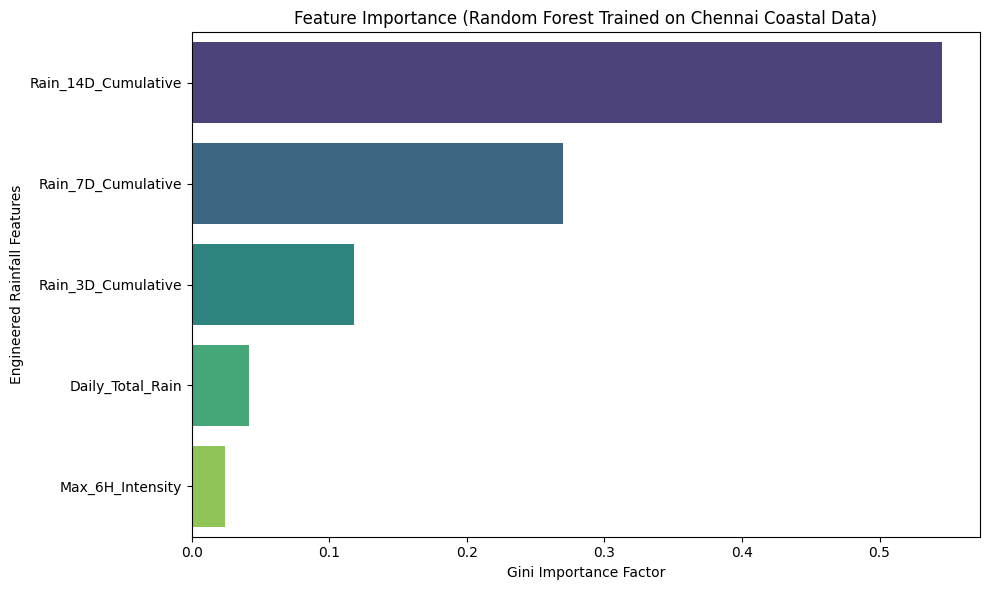

In [8]:
# Extract feature importances from the trained Random Forest
importances = rf_model.feature_importances_

# Create a DataFrame to sort the features by importance for a cleaner plot
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the sorted feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette="viridis")
plt.title("Feature Importance (Random Forest Trained on Chennai Coastal Data)")
plt.xlabel("Gini Importance Factor")
plt.ylabel("Engineered Rainfall Features")
plt.tight_layout()
plt.show()

## Step 9: Trend Visualizations

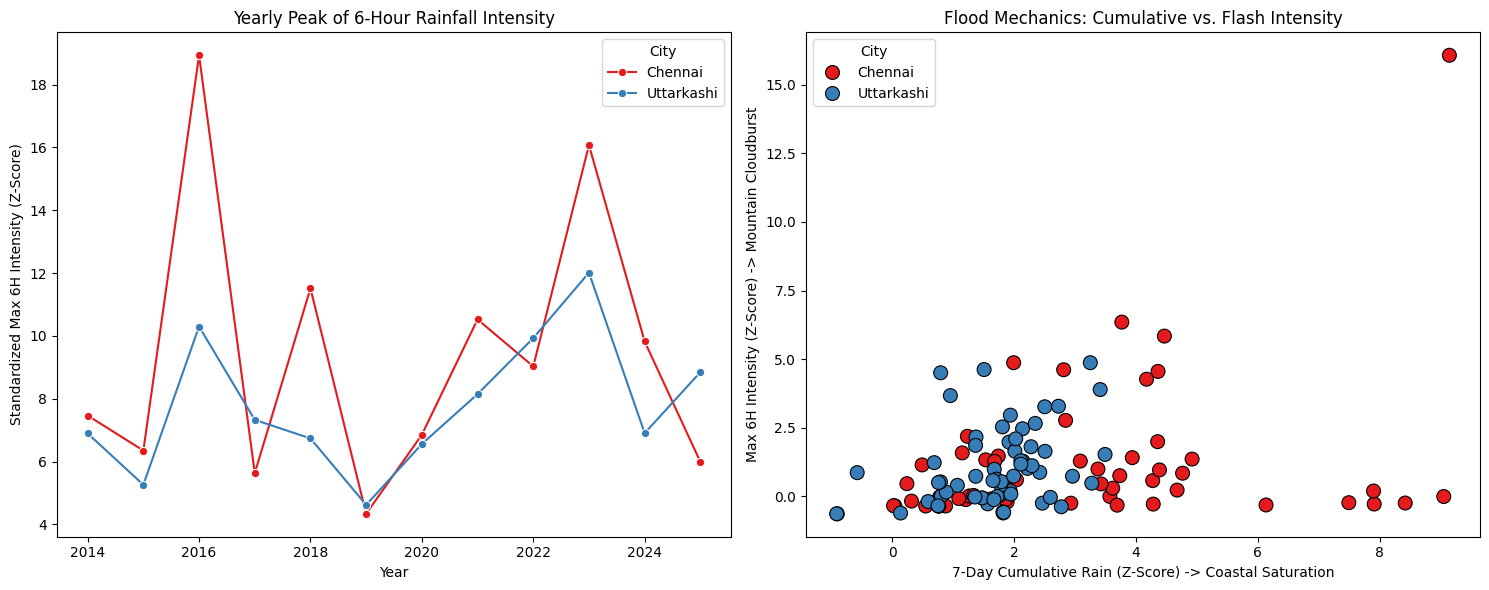

In [9]:
# Combine datasets for visualization
df_combined = pd.concat([df_chennai, df_val])

# Re-extract Year for trend plotting
df_combined['Year'] = df_combined['Date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Trend of Extreme Intensity (Yearly Max of 6H Intensity)
# We take the max() to see how the worst single day of each year compares across terrains
yearly_max = df_combined.groupby(['Year', 'City'])['Max_6H_Intensity'].max().reset_index()
sns.lineplot(data=yearly_max, x='Year', y='Max_6H_Intensity', hue='City', marker='o', palette='Set1', ax=axes[0])
axes[0].set_title("Yearly Peak of 6-Hour Rainfall Intensity")
axes[0].set_ylabel("Standardized Max 6H Intensity (Z-Score)")
axes[0].set_xlabel("Year")

# Plot 2: Scatter plot of flooding mechanisms (FLOOD DAYS ONLY)
flood_days = df_combined[df_combined['Flood_Label'] == 1]
sns.scatterplot(data=flood_days, x='Rain_7D_Cumulative', y='Max_6H_Intensity', hue='City', s=100, palette='Set1', edgecolor='black', ax=axes[1])
axes[1].set_title("Flood Mechanics: Cumulative vs. Flash Intensity")
axes[1].set_xlabel("7-Day Cumulative Rain (Z-Score) -> Coastal Saturation")
axes[1].set_ylabel("Max 6H Intensity (Z-Score) -> Mountain Cloudburst")

plt.tight_layout()
plt.show()

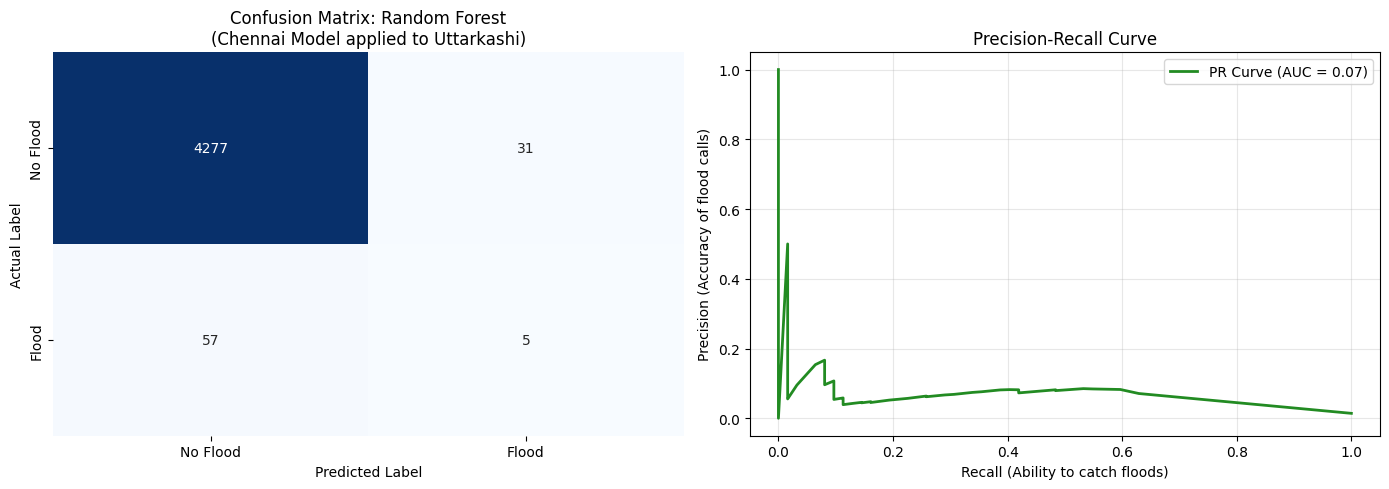

In [10]:
# 1. Plot Professional Confusion Matrix Heatmap
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_val, rf_model.predict(X_val))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Flood', 'Flood'], 
            yticklabels=['No Flood', 'Flood'])
plt.title("Confusion Matrix: Random Forest\n(Chennai Model applied to Uttarkashi)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# 2. Plot Precision-Recall Curve
# This is better than ROC-AUC for imbalanced flood data
plt.subplot(1, 2, 2)
y_probs = rf_model.predict_proba(X_val)[:, 1]
precision, recall, _ = precision_recall_curve(y_val, y_probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='forestgreen', lw=2)
plt.xlabel('Recall (Ability to catch floods)')
plt.ylabel('Precision (Accuracy of flood calls)')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
print("--- FINAL QUANTITATIVE ANALYSIS ---")
missed_floods = cm[1,0]
total_actual_floods = cm[1,0] + cm[1,1]
print(f"Total Actual Floods in Uttarkashi: {total_actual_floods}")
print(f"Floods MISSED by Chennai Model: {missed_floods} ({ (missed_floods/total_actual_floods)*100 :.1f}%)")
print(f"Conclusion: The model lacks transferability to mountain terrains due to 'Intensity-Saturation' mismatch.")

--- FINAL QUANTITATIVE ANALYSIS ---
Total Actual Floods in Uttarkashi: 62
Floods MISSED by Chennai Model: 57 (91.9%)
Conclusion: The model lacks transferability to mountain terrains due to 'Intensity-Saturation' mismatch.
